In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from scipy.interpolate import griddata
from tabulate import tabulate
from skimage.metrics import structural_similarity as ssim
import scipy.ndimage as ndimage
from skimage.draw import polygon
from tqdm import tqdm
from scipy.ndimage import distance_transform_edt

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

num_epochs = 3000
batch_size = 128
learning_rate = 0.0001

In [24]:
import matplotlib as mpl

def set_plot_params():
    """
    Matplotlib's rcParams for consistent, publication-quality plots.
    """
    ## Figure settings
    mpl.rcParams['figure.figsize'] = (8, 6)       # Figure size in inches
    mpl.rcParams['figure.dpi'] = 100              # (Display) Figure resolution
    mpl.rcParams['savefig.dpi'] = 300             # Resolution when saving figures

    ## Font settings (Standard 16-14-12 config.)
    mpl.rcParams['font.family'] = 'serif'         # Serif fonts
    mpl.rcParams['font.size'] = 12                # Base font size
    mpl.rcParams['axes.titlesize'] = 16           # Title font size for axes
    mpl.rcParams['axes.labelsize'] = 14           # Font size for x and y labels
    mpl.rcParams['xtick.labelsize'] = 12          # Font size for x-tick labels
    mpl.rcParams['ytick.labelsize'] = 12          # Font size for y-tick labels
    mpl.rcParams['legend.fontsize'] = 12          # Legend font size

    ## Line settings
    mpl.rcParams['lines.linewidth'] = 2           # Default line width
    mpl.rcParams['lines.markersize'] = 6          # Marker size for plots

    ## Contour plot settings
    mpl.rcParams['contour.negative_linestyle'] = 'solid'

    ## Grid settings
    mpl.rcParams['grid.linestyle'] = '--'
    mpl.rcParams['grid.color'] = 'gray'
    mpl.rcParams['grid.alpha'] = 0.5

    ## Color presets (Plasma-ish color scheme)
    mpl.rcParams['image.cmap'] = 'plasma' # Can be changed to "jet", "viridis", etc.

    ## Default color cycle for line plots using the plasma colormap.
    plasma_cmap = mpl.cm.get_cmap('plasma') # Can be changed to "jet", "viridis", etc.
    num_colors = 10
    colors = [plasma_cmap(i) for i in np.linspace(0, 1, num_colors)]
    mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=colors)

Generating NACA 4-Digit Airfoils: 100%|██████████| 1250/1250 [00:14<00:00, 85.06it/s]


Dataset generation complete!


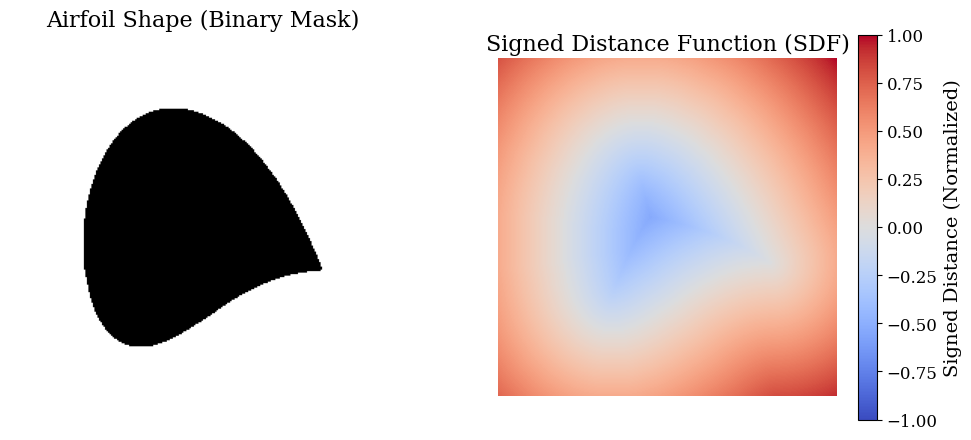

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt
from skimage.draw import polygon
from tqdm import tqdm

# Function to generate a NACA 4-digit airfoil
def naca4_series(m, p, t, num_points=100):
    x = np.linspace(0, 1, num_points)  # Chord-wise x-coordinates

    # Mean Camber Line Equation
    if p == 0:
        yc = np.zeros_like(x)
        dyc_dx = np.zeros_like(x)
    else:
        yc = np.where(x < p, (m / p**2) * (2 * p * x - x**2), 
                      (m / (1 - p)**2) * ((1 - 2*p) + 2*p*x - x**2))
        dyc_dx = np.where(x < p, (2 * m / p**2) * (p - x),
                          (2 * m / (1 - p)**2) * (p - x))

    theta = np.arctan(dyc_dx)

    # Thickness distribution
    yt = 5 * t * (0.2969 * np.sqrt(x) - 0.1260 * x - 0.3516 * x**2 + 0.2843 * x**3 - 0.1036 * x**4)

    # Compute upper and lower surface coordinates
    xu = x - yt * np.sin(theta)
    xl = x + yt * np.sin(theta)
    yu = yc + yt * np.cos(theta)
    yl = yc - yt * np.cos(theta)

    # Combine upper and lower surfaces
    X = np.concatenate((xu, xl[::-1]))
    Y = np.concatenate((yu, yl[::-1]))

    return X, Y

# Function to embed airfoil into a [-3,3]x[-3,3] domain
def airfoil_to_large_grid(x, y, grid_size=256, airfoil_size=128):

    # Normalize airfoil to fit within [0,1] range
    x_scaled = (x - np.min(x)) / (np.max(x) - np.min(x)) * (airfoil_size - 1)
    y_scaled = (y - np.min(y)) / (np.max(y) - np.min(y)) * (airfoil_size - 1)

    # Center airfoil in [-3,3] domain
    x_shifted = x_scaled + (grid_size - airfoil_size) // 2
    y_shifted = y_scaled + (grid_size - airfoil_size) // 2

    # Ensure valid indices
    x_shifted = np.clip(x_shifted, 0, grid_size - 1)
    y_shifted = np.clip(y_shifted, 0, grid_size - 1)

    # Create binary mask
    img = np.ones((grid_size, grid_size), dtype=np.uint8)
    rr, cc = polygon(y_shifted, x_shifted, img.shape)
    img[rr, cc] = 0  # Mark airfoil region

    return img

# Function to compute signed distance function (SDF) normalized between [-1, 1]
def compute_signed_distance(airfoil_mask):
    # Compute unsigned distance from airfoil boundary
    sdf_outside = distance_transform_edt(airfoil_mask)  # Outside distance
    sdf_inside = distance_transform_edt(1 - airfoil_mask)  # Inside distance

    # Compute signed distance (positive outside, negative inside)
    sdf = sdf_outside - sdf_inside

    # Normalize to range [-1, 1]
    max_distance = np.max(np.abs(sdf))  # Maximum absolute value
    sdf = sdf / max_distance  # Scale to [-1, 1]

    # Ensure zero SDF at the airfoil boundary
    boundary_mask = np.logical_and(airfoil_mask == 0, 
                                   np.logical_and(distance_transform_edt(airfoil_mask) > 0, 
                                                  distance_transform_edt(1 - airfoil_mask) > 0))
    sdf[boundary_mask] = 0  # Set airfoil boundary explicitly to zero

    return sdf


# Number of airfoils to generate
num_airfoils = 1250
grid_size = 256  # Computational domain size [-3,3]
airfoil_size = 160  # Airfoil remains within [0,1]

# Arrays to store generated data
airfoil_shapes = np.zeros((num_airfoils, grid_size, grid_size), dtype=np.uint8)
sdf_solutions = np.zeros((num_airfoils, grid_size, grid_size), dtype=np.float32)

# Generate dataset
for i in tqdm(range(num_airfoils), desc="Generating NACA 4-Digit Airfoils"):
    # Generate random NACA 4-digit airfoil parameters
    m = random.uniform(0.01, 0.09)  # Max camber (as fraction of chord)
    p = random.uniform(0.05, 0.9)  # Position of max camber
    t = random.uniform(0.01, 0.4)  # Thickness

    # Generate airfoil shape
    x, y = naca4_series(m, p, t)

    # Convert airfoil to binary grid in larger [-3,3] domain
    airfoil_mask = airfoil_to_large_grid(x, y, grid_size, airfoil_size)

    # Compute normalized signed distance function (SDF)
    sdf = compute_signed_distance(airfoil_mask)

    # Store data
    airfoil_shapes[i, :, :] = airfoil_mask
    sdf_solutions[i, :, :] = sdf

# Save dataset
np.save("airfoil_shapes.npy", airfoil_shapes)
np.save("sdf_solutions.npy", sdf_solutions)

print("Dataset generation complete!")

# Visualization of a random airfoil and its SDF
idx = random.randint(0, num_airfoils - 1)
plt.figure(figsize=(12, 5))

# Plot airfoil shape
plt.subplot(1, 2, 1)
plt.imshow(airfoil_shapes[idx], cmap="gray", origin="lower")
plt.title("Airfoil Shape (Binary Mask)")
plt.axis("off")

# Plot normalized SDF solution
plt.subplot(1, 2, 2)
plt.imshow(sdf_solutions[idx], cmap="coolwarm", origin="lower", vmin=-1, vmax=1)
plt.colorbar(label="Signed Distance (Normalized)")
plt.title("Signed Distance Function (SDF)")
plt.axis("off")

plt.show()


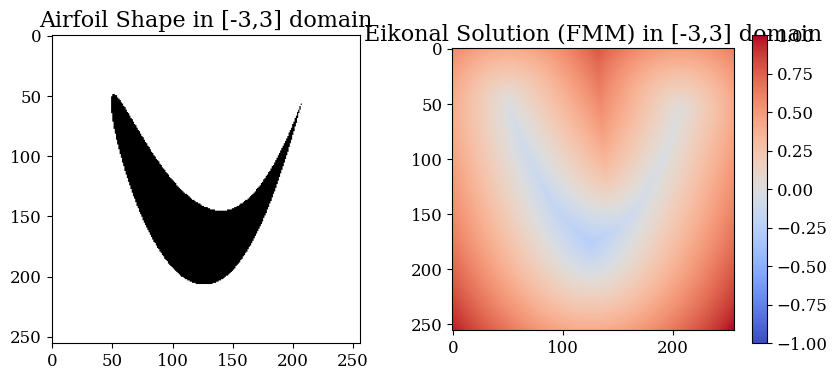

In [34]:
# Load saved data
airfoil_shapes = np.load("airfoil_shapes.npy")
eikonal_solutions = np.load("sdf_solutions.npy")

# Select a random sample
idx = random.randint(0, 500)
airfoil_sample = airfoil_shapes[idx, :, :]
eikonal_sample = eikonal_solutions[idx, :, :]

# Plot the airfoil and its corresponding solution
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(airfoil_sample, cmap="gray")
plt.title("Airfoil Shape in [-3,3] domain")

plt.subplot(1, 2, 2)
plt.imshow(eikonal_sample, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Eikonal Solution (FMM) in [-3,3] domain")
plt.colorbar()
plt.show()


In [35]:
a_samples = np.load('airfoil_shapes.npy')
u_samples = np.load('sdf_solutions.npy')

print(u_samples.shape)
print(a_samples.shape)


(1250, 256, 256)
(1250, 256, 256)


C:\Users\asojitra\AppData\Local\Temp\ipykernel_6528\1417028665.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plasma_cmap = mpl.cm.get_cmap('plasma') # Can be changed to "jet", "viridis", etc.


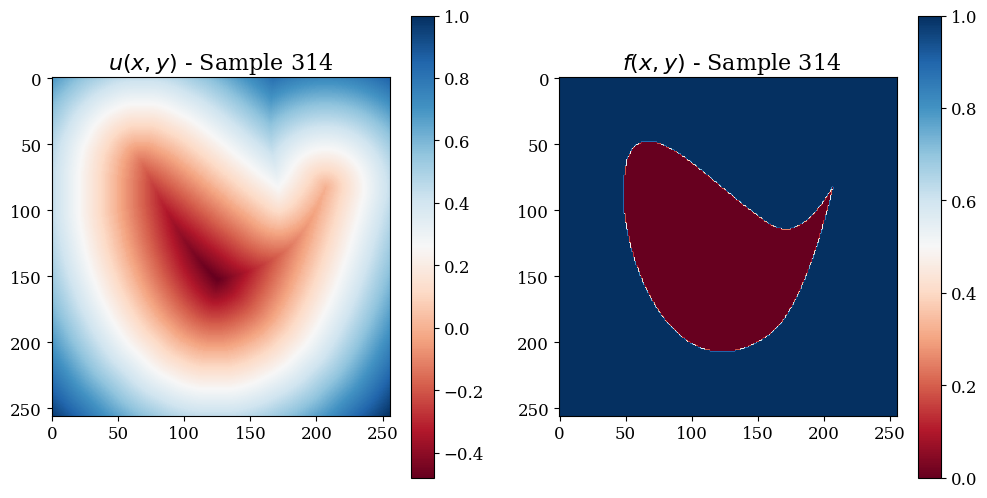

In [36]:
sample_idx = random.randint(0, u_samples.shape[0])
set_plot_params()
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title(f'$u(x,y)$ - Sample {sample_idx}')
plt.imshow(u_samples[sample_idx], cmap='RdBu')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.title(f' $f(x,y)$ - Sample {sample_idx}')
plt.imshow(a_samples[sample_idx], cmap='RdBu')
plt.colorbar()

plt.show()